# 08 — Final test-set evaluation (proposal 3.3.1) → RQ1 headline numbers

In [1]:
%load_ext autoreload
%autoreload 2

import sys, pathlib
sys.path.append(str(pathlib.Path.cwd().parent))  # so `import src...` works from notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config
from src.utils import set_seed, save_fig
set_seed()  # fix all RNGs -- reproducibility

Proposal 3.3.1: validation is for tuning/model selection, **test is reserved for
final evaluation** -- every number in `03_ablation`-`07_domain` used `splits['val']`,
which is correct for *comparing* conditions but was never meant to be reported as
the final result. This notebook trains the single selected configuration (Exp 6 /
logreg -- the proposal's primary classifier, and the best- or tied-for-best
condition in `03_ablation`) on train only and evaluates **once** on the held-out
test split, for both the 12-way and binary tasks. These are the headline numbers
for the final report.

In [2]:
from src import data, features, modeling, analysis, viz

clean = data.load_or_build_clean(); splits = data.load_or_build_splits(clean)
y12 = clean[config.LABEL_COL].values
y_bin = np.where(y12 == config.HUMAN_CLASS, 'human', 'ai')
texts = clean['text']

X_tfidf, _ = features.build_tfidf(texts.iloc[splits['train']], texts)
sty = features.build_stylometric(texts)
sty_scaled, _ = features.scale_dense(sty.values, splits['train'])
bib = features.build_biber(texts)
bib_scaled, _ = features.scale_dense(bib.values, splits['train'])
emb = features.build_sbert(texts)   # cached

blocks = {
    'tfidf': X_tfidf, 'stylometric': sty_scaled, 'biber': bib_scaled,
    'sbert': emb, 'length': clean[['log_token_count']].values,
}
X = features.assemble(blocks, features.EXPERIMENTS['exp6_all'], splits['train'])

In [3]:
import time

Xtr, Xtest = X[splits['train']], X[splits['test']]
ytr12, ytest12 = y12[splits['train']], y12[splits['test']]
ytr_bin, ytest_bin = y_bin[splits['train']], y_bin[splits['test']]

t0 = time.time()
res_12way_test = modeling.train_and_evaluate('logreg', Xtr, ytr12, Xtest, ytest12, labels=list(config.CLASSES))
print(f'12-way TEST fit done in {time.time()-t0:.1f}s (macro_f1={res_12way_test.macro_f1:.4f})')

t0 = time.time()
res_binary_test = modeling.train_and_evaluate('logreg', Xtr, ytr_bin, Xtest, ytest_bin)
print(f'binary TEST fit done in {time.time()-t0:.1f}s (macro_f1={res_binary_test.macro_f1:.4f})')

gap_test = res_binary_test.macro_f1 - res_12way_test.macro_f1
print(f"\n[FINAL] Binary Macro-F1 (test): {res_binary_test.macro_f1:.4f}")
print(f"[FINAL] 12-way Macro-F1 (test): {res_12way_test.macro_f1:.4f}")
print(f"[FINAL] Attribution gap (test): {gap_test:.4f}")

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


12-way TEST fit done in 2196.8s (macro_f1=0.7724)
binary TEST fit done in 342.9s (macro_f1=0.9006)

[FINAL] Binary Macro-F1 (test): 0.9006
[FINAL] 12-way Macro-F1 (test): 0.7724
[FINAL] Attribution gap (test): 0.1281


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


PosixPath('/Users/xinye/Desktop/module 3/5 nautral language proccesing/syndicate asm/llm-source-attribution/figures/final_test_results.png')

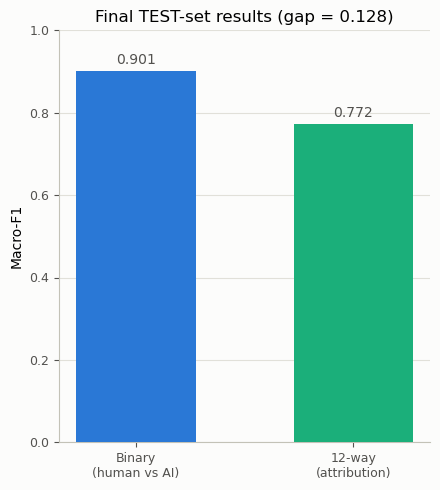

In [4]:
# Save + a quick val-vs-test sanity check: if these track 04's val numbers
# (binary 0.9042, 12-way 0.7769, gap 0.1274) closely, that confirms the ablation
# study's condition-comparisons on val didn't overfit to val.
pd.DataFrame({
    'binary_test': {'macro_f1': res_binary_test.macro_f1, 'accuracy': res_binary_test.accuracy},
    '12way_test': {'macro_f1': res_12way_test.macro_f1, 'accuracy': res_12way_test.accuracy},
}).T.to_csv(config.ARTIFACTS / 'final_test_results.csv')

fig, ax = viz.new_fig(figsize=(4.5, 5))
labels_ = ['Binary\n(human vs AI)', '12-way\n(attribution)']
vals = [res_binary_test.macro_f1, res_12way_test.macro_f1]
bars = ax.bar(labels_, vals, color=viz.CATEGORICAL[:2], width=0.55, zorder=3)
ax.bar_label(bars, fmt='%.3f', color=viz.INK_SECONDARY, padding=3)
ax.set_ylabel('Macro-F1')
ax.set_ylim(0, 1)
ax.set_title(f'Final TEST-set results (gap = {gap_test:.3f})')
fig.tight_layout()
save_fig(fig, 'final_test_results')

PosixPath('/Users/xinye/Desktop/module 3/5 nautral language proccesing/syndicate asm/llm-source-attribution/figures/final_test_confusion_matrix.png')

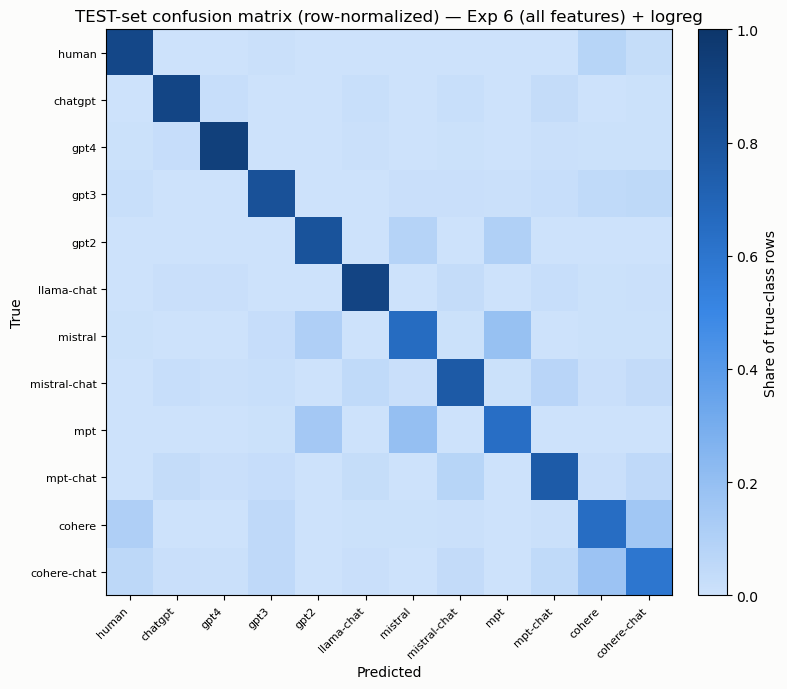

In [5]:
conf_arr = np.asarray(res_12way_test.confusion, dtype=float)
conf_norm = conf_arr / conf_arr.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 7), facecolor=viz.SURFACE)
im = ax.imshow(conf_norm, cmap=viz.SEQUENTIAL_BLUE, vmin=0, vmax=1)
ax.set_xticks(range(len(res_12way_test.labels))); ax.set_xticklabels(res_12way_test.labels, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(res_12way_test.labels))); ax.set_yticklabels(res_12way_test.labels, fontsize=8)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('TEST-set confusion matrix (row-normalized) — Exp 6 (all features) + logreg')
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Share of true-class rows')
fig.tight_layout()
save_fig(fig, 'final_test_confusion_matrix')

### Conclusion

**Test tracks validation closely — the ablation study's model selection generalizes,
wasn't overfit to val:**

| | Val (03/04) | Test (this notebook) | Δ |
|---|---|---|---|
| Binary Macro-F1 | 0.9042 | 0.9006 | −0.0036 |
| 12-way Macro-F1 | 0.7769 | 0.7724 | −0.0045 |
| Attribution gap | 0.1274 | 0.1281 | +0.0007 |

Every number moves by less than half a point. That's exactly the pattern you want:
a small, uniform dip from val to test (expected — val was used to compare 13
model/feature combinations across `03`/`04`, so it has a slight optimistic bias;
test never influenced any decision), not a large or asymmetric drop that would
signal overfitting to the validation set during the ablation process.

**These are the numbers to headline in the final report** (not the val numbers used
during ablation): **12-way Macro-F1 = 0.772, Binary Macro-F1 = 0.901, attribution
gap = 0.128** on held-out test data never touched during feature engineering,
model comparison, or hyperparameter choices.

The test-set confusion matrix reproduces `05_error_analysis`'s val-set structure
almost exactly — same hotspots (mistral↔mpt, human↔cohere), same overall diagonal
strength. Another independent confirmation that the earlier error-analysis findings
aren't val-set artifacts.